In [38]:
import numpy as np
import matplotlib.pyplot as plt
import torch
torch.manual_seed(0)

import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from neural_decoder.neural_decoder_trainer import getDatasetLoaders

In [39]:
trainLoader, testLoader, loadedData = getDatasetLoaders(
    "../data/ptDecoder_ctc",
    batchSize=1,
)

In [40]:
num_trials = 8800
num_channels = 128
num_feats = 2

# buffers: one list per channel per feature
# buffers[feature][channel] = list of segments
buffers = [[[] for _ in range(num_channels)] for _ in range(num_feats)]

for _ in range(num_trials):
    X, _, _, _, _ = next(iter(trainLoader))
    X = X.squeeze().numpy()
    L = X.shape[0]

    # reshape into (L, 2, 128)
    trial_fc = X.reshape(L, num_feats, num_channels)

    # for each feature
    for f in range(num_feats):
        data_f = trial_fc[:, f, :]  # (L, 128)

        # split per channel
        for ch in range(num_channels):
            buffers[f][ch].append(data_f[:, ch])

In [41]:
# final vectors: feature × channel × samples
channel_vectors = [
    [np.concatenate(buffers[f][ch]) for ch in range(num_channels)]
    for f in range(num_feats)
]

# compute correlations feature-wise
corr_matrices = [
    np.corrcoef(np.vstack(channel_vectors[f]))
    for f in range(num_feats)
]

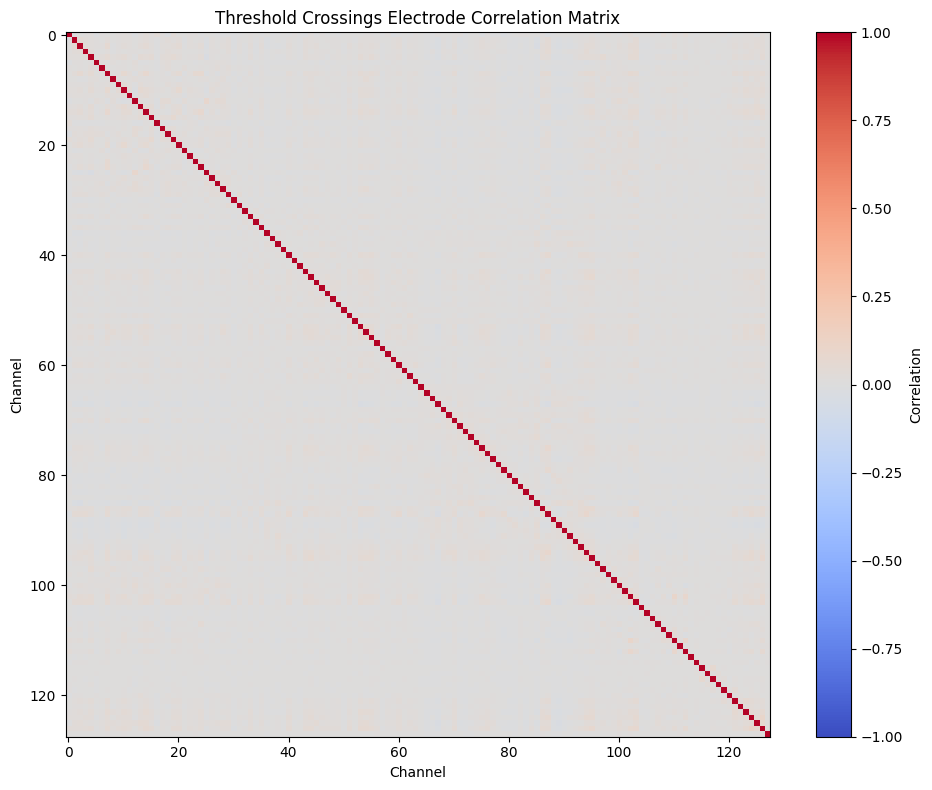

In [42]:
plt.figure(figsize=(10, 8))
plt.imshow(corr_matrices[0], cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.title("Threshold Crossings Electrode Correlation Matrix")
plt.xlabel("Channel")
plt.ylabel("Channel")
plt.tight_layout()
plt.show()

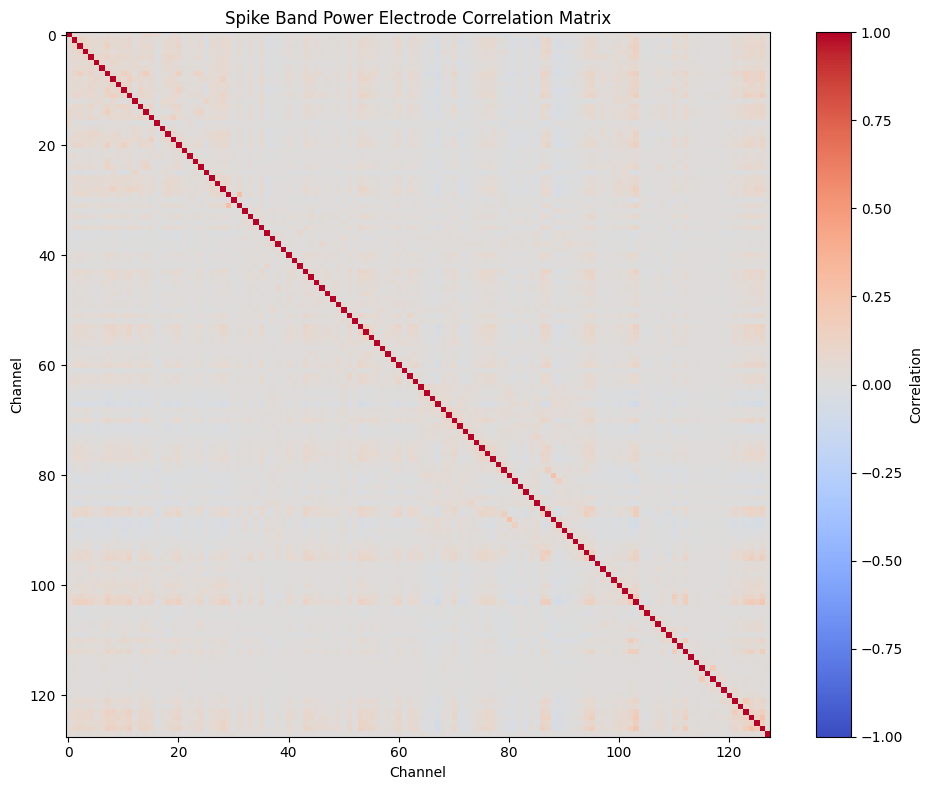

In [43]:
plt.figure(figsize=(10, 8))
plt.imshow(corr_matrices[1], cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.title("Spike Band Power Electrode Correlation Matrix")
plt.xlabel("Channel")
plt.ylabel("Channel")
plt.tight_layout()
plt.show()

In [52]:
tc = corr_matrices[0].copy()
np.fill_diagonal(tc, 0)

sbp = corr_matrices[1].copy()
np.fill_diagonal(sbp, 0)

product = (tc + sbp) / 2

In [53]:
sorted_indices_flat = np.argsort(product.ravel())[::-1]

rows, cols = np.unravel_index(sorted_indices_flat, product.shape)
sorted_indices = list(zip(rows, cols))
sorted_indices = sorted_indices[::2] # remove duplicates (i,j) and (j,i)

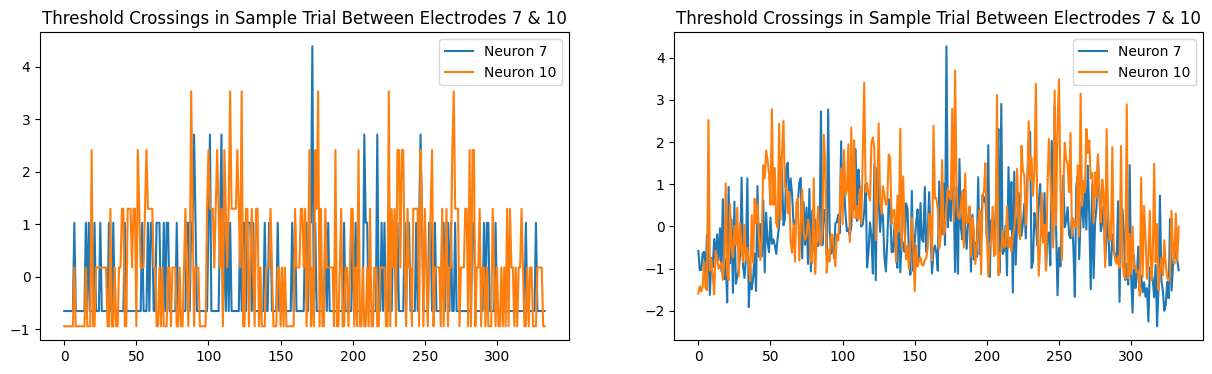

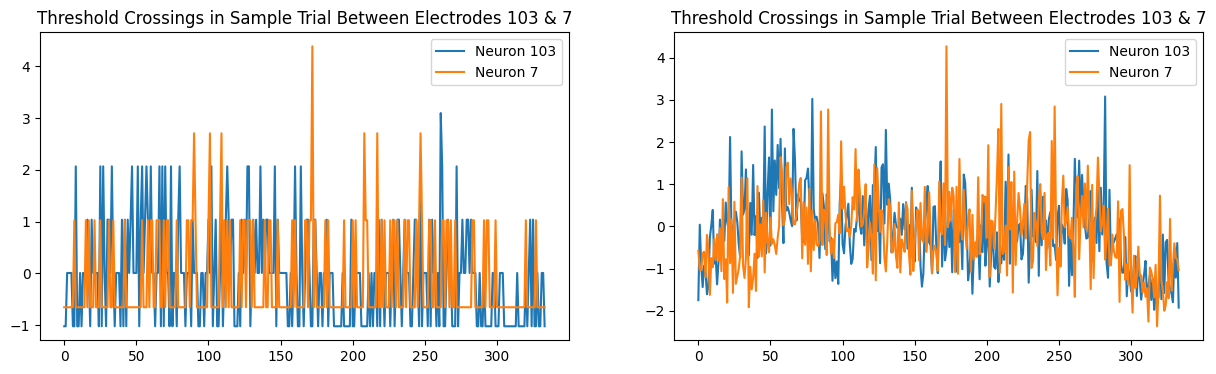

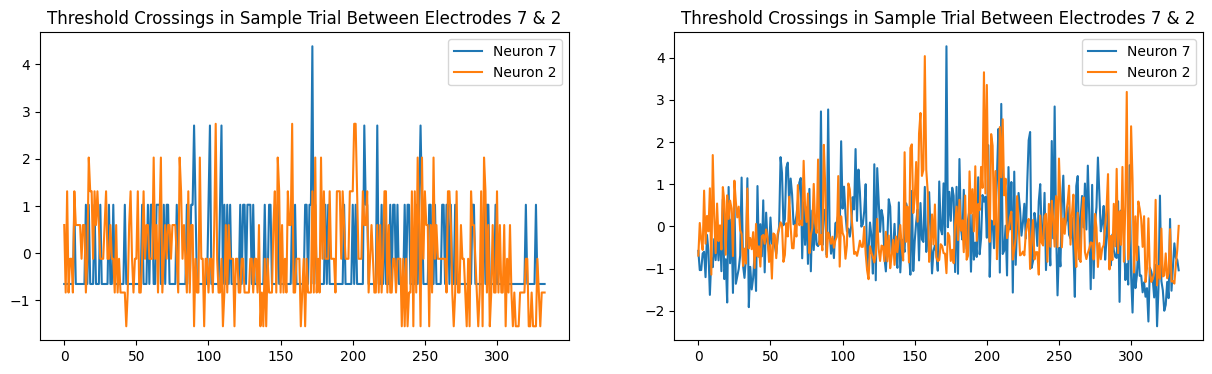

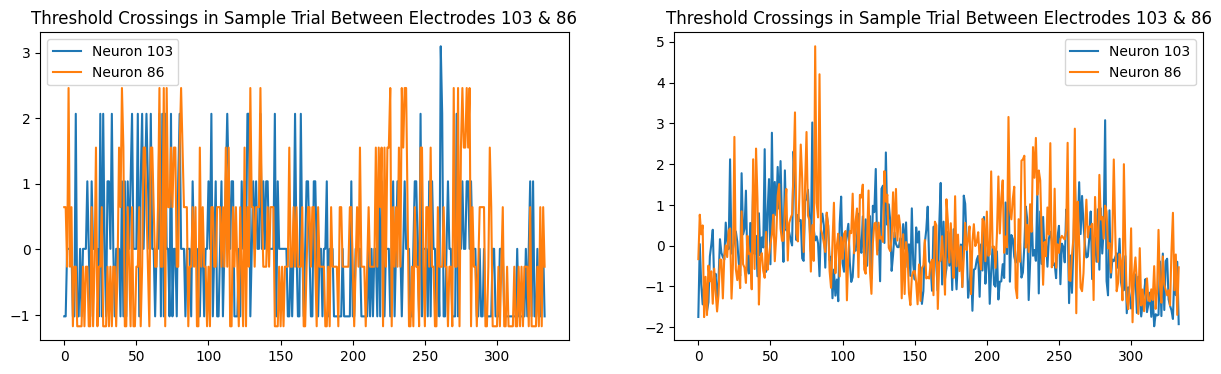

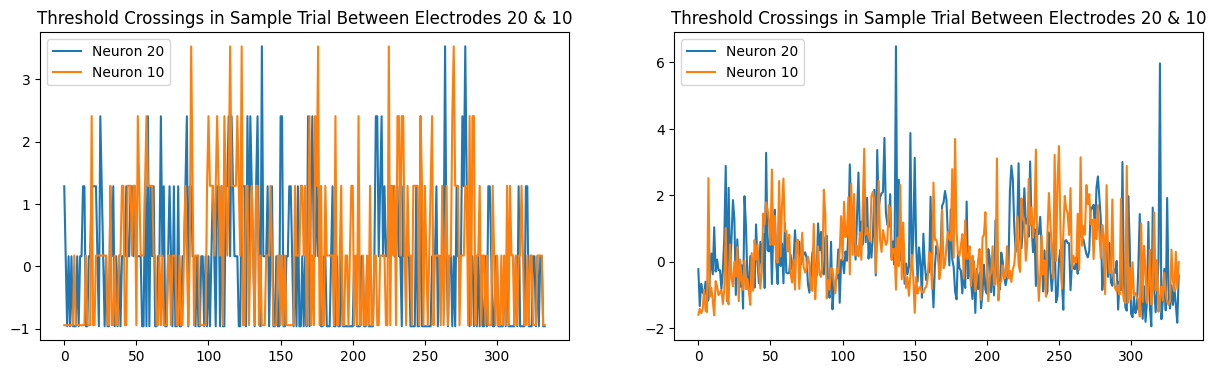

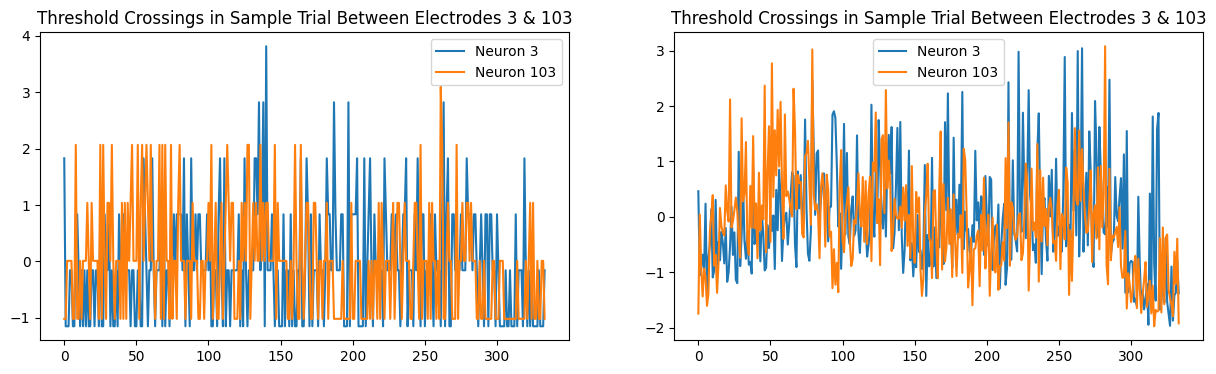

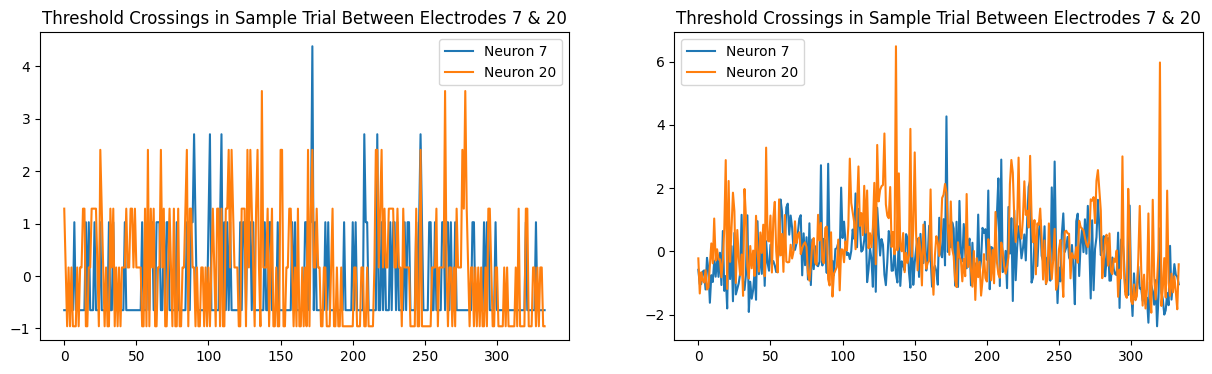

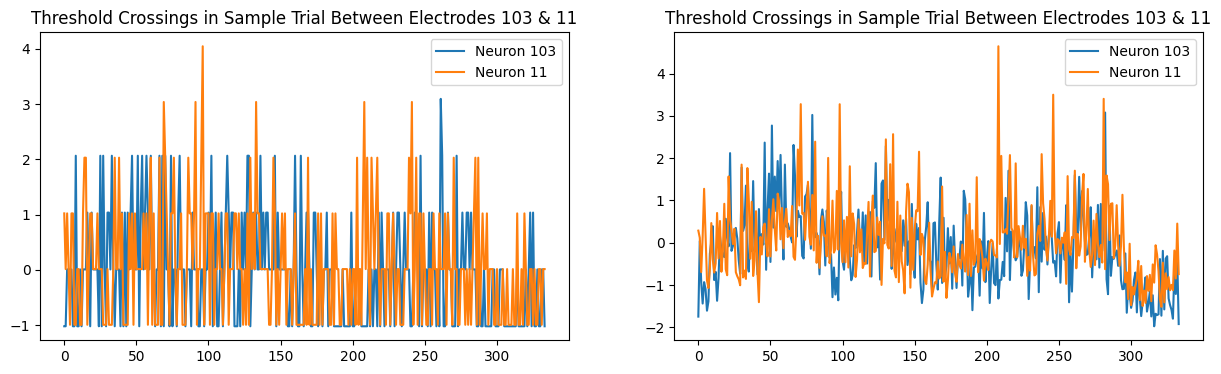

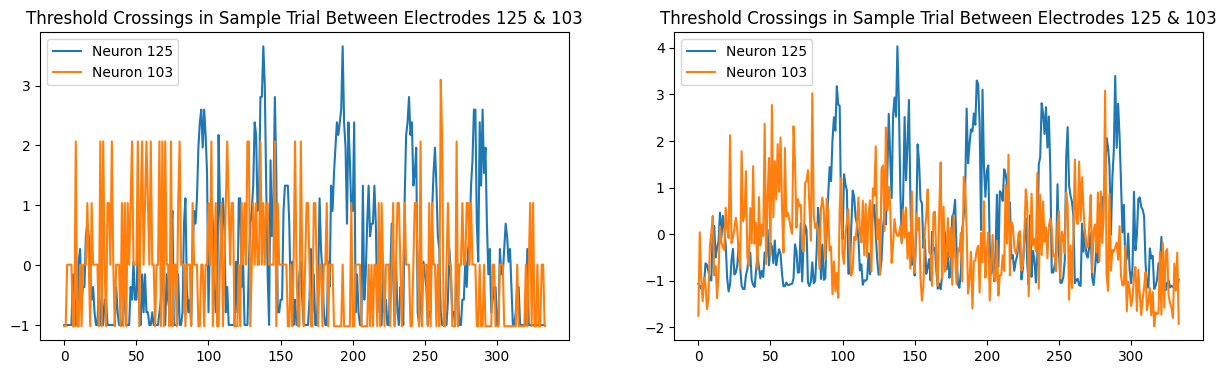

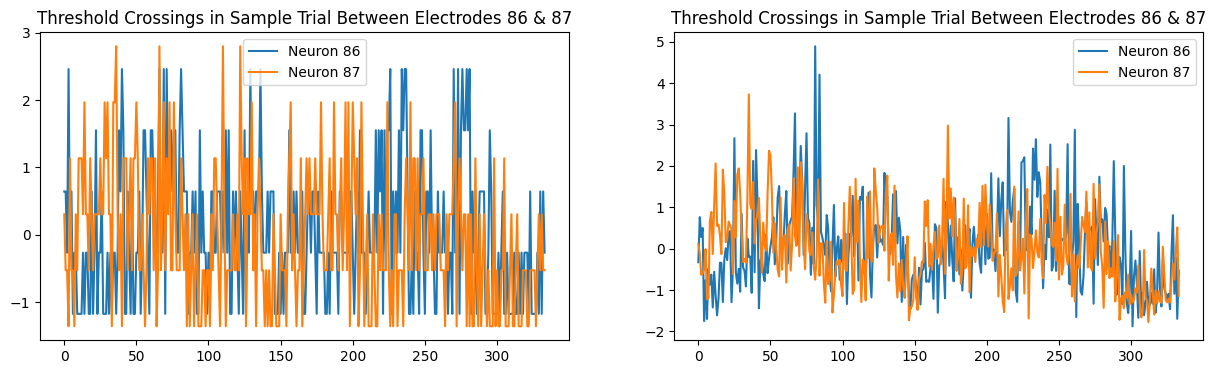

In [59]:
for electrode1, electrode2 in sorted_indices[:10]:
    plt.figure(figsize=(15, 4))
    plt.subplot(1, 2, 1)
    plt.plot(np.arange(X[:, electrode1].shape[0]), X[:, electrode1], label=f"Neuron {electrode1}")
    plt.plot(np.arange(X[:, electrode2].shape[0]), X[:, electrode2], label=f"Neuron {electrode2}")
    plt.title(f"Threshold Crossings in Sample Trial Between Electrodes {electrode1} & {electrode2}")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(np.arange(X[:, electrode1+128].shape[0]), X[:, electrode1+128], label=f"Neuron {electrode1}")
    plt.plot(np.arange(X[:, electrode2+128].shape[0]), X[:, electrode2+128], label=f"Neuron {electrode2}")
    plt.title(f"Threshold Crossings in Sample Trial Between Electrodes {electrode1} & {electrode2}")
    plt.legend()
    plt.show()

As we can see, many of these neurons are highly correlated with each other. Thus, it seems plausible that we can achieve similar model performance by dropping some of the highly correlated neurons in our data. So if we want to drop k neurons, we can find the k neurons with the highest correlation and then drop one of the two neurons in each of those pairs.

In [ ]:
sorted_indices[:20]

[(126, 124),
 (31, 29),
 (80, 88),
 (103, 126),
 (102, 110),
 (117, 115),
 (112, 110),
 (103, 124),
 (103, 87),
 (94, 87),
 (103, 102),
 (102, 112),
 (121, 123),
 (112, 126),
 (125, 126),
 (126, 95),
 (94, 95),
 (14, 7),
 (95, 86),
 (126, 123)]

In [ ]:
drop = set()
keep = set()

while (len(sorted_indices) > 0) & (len(drop) < 10):
    electrode1, electrode2 = sorted_indices.pop(0)
    if (
        (electrode1 not in drop and electrode2 not in drop) and
        (electrode1 not in keep and electrode2 not in keep)
    ):
         if np.random.rand() < 0.5:
            drop.add(electrode1)
            keep.add(electrode2)
         else:
            drop.add(electrode2)
            keep.add(electrode1)

In [ ]:
drop

{7, 19, 29, 80, 87, 94, 110, 115, 121, 124}

In [ ]:
keep

{14, 15, 31, 88, 95, 102, 103, 117, 123, 126}